# Supercooled liquid vs all cloud liquid at Utqiaġvik

How much cloud time changes when **supercooled** liquid water (`tcslw`) is
counted instead of **all** cloud liquid water (`tclw`)? Every other threshold is
held fixed, so any difference is attributable to the swap alone.
`check_comparable` enforces that and raises rather than letting a stray
difference read as a supercooled-water effect.

Categories are exactly those in `comparison_with_Genie_Obs.ipynb`:

| category | definition (LWP = whichever liquid field is in use) |
|---|---|
| liquid only | LWP/(LWP+IWP) ≥ `liquid_fraction_min` = 0.90 |
| ice only | IWP/(LWP+IWP) ≥ `ice_fraction_min` = 0.85, i.e. LWP/(LWP+IWP) ≤ 0.15 |
| mixed phase | any remaining scene holding cloud water |
| liquid containing | liquid only **+** mixed phase, i.e. LWP/(LWP+IWP) > 0.15 |

Both numerator and denominator use the selected liquid field, so the ratio is
computed self-consistently. Minimum paths (0.01 g m⁻² each) are applied
*before* the ratio; a species under its floor is zeroed. The "no phase"
residual is folded into ice-only, so the categories sum to the overcast total.

---

## ⚠ The two fields are not the same kind of product

`tclw` and `tcslw` do not come from the same model stream:

| field | source | lead |
|---|---|---|
| `tclw` | 4D-Var **analysis** at that hour (step 0), constrained by every observation in the 12-hour window | 0 |
| `tcslw` | free-running short **forecast**, initialised at 06 and 18 UTC | 1–12 h |

So the forecast lead is a deterministic function of UTC hour — step 1 at 07 and
19 UTC, rising to step 12 at 18 and 06 UTC. **Section 1 tests that prediction
and confirms it.** Most of the apparent disagreement between the two fields is
forecast error, not a difference between supercooled and total liquid.

This was not obvious. Before the forecast structure was known, three candidate
explanations were tested and rejected: precipitating liquid folded into
`tcslw` (`tcrw` is below the storage quantum in 99% of exceeding cells), a
time-axis offset (lag-0 correlation 0.938 beats lag ±1 at 0.886/0.898), and
ordinary quantisation (the excess survives a full-quantum margin). All three
missed the point, because they looked for a difference *within* the physics of
two fields that are not comparable products in the first place.

**What follows from it:** eighteen hours in every twenty-four carry a lead of 4
or more, so an all-hours comparison is dominated by forecast error. Sections 3–7
use all 24 hours; **section 8 repeats the comparison restricted to forecast
steps 1–3** (07–09 and 19–21 UTC), which is as close to an analysis-vs-analysis
comparison as these fields allow. Read the two together: the difference between
them is the forecast-error contribution.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph
import compare_liquid_definitions as cld

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

SAVE_DIR = Path("figures/liquid_definitions")

## 2. Load both runs

Identical settings but for `liquid_var`. These match
`comparison_with_Genie_Obs.ipynb` so the numbers are directly comparable
between the two notebooks.

## 1. Is `tcslw` a forecast? The falsifiable test

If the analysis/forecast split is the cause, binning `tcslw − tclw` by UTC hour
must give a **sawtooth**: near-zero at 07 and 19 UTC, growing monotonically to a
maximum at 18 and 06 UTC, with sharp discontinuities across 18→19 and 06→07. No
other candidate explanation predicts that shape.

This reads the raw fields directly — none of this notebook's phase logic is in
the way.

20 files, 5,760 time steps

 UTC  lead   RMS diff     corr  exceed %
   0     6      7.595   0.9462     33.66
   1     7      7.692   0.9431     33.32
   2     8      8.200   0.9334     32.97
   3     9      9.037   0.9173     32.37
   4    10      9.297   0.9159     31.23
   5    11      9.706   0.9101     31.73
   6    12     10.241   0.9034     31.45
   7     1      3.465   0.9905     19.11   <- forecast re-initialised
   8     2      3.871   0.9876     22.10
   9     3      4.439   0.9837     22.74
  10     4      7.279   0.9484     26.90
  11     5      7.819   0.9395     28.85
  12     6      8.301   0.9359     30.29
  13     7      8.895   0.9312     31.50
  14     8      9.878   0.9172     31.09
  15     9     10.089   0.9133     32.32
  16    10     10.233   0.9131     31.38
  17    11     10.070   0.9136     31.63
  18    12     10.266   0.9076     30.80
  19     1      3.569   0.9904     18.09   <- forecast re-initialised
  20     2      4.013   0.9878     21.17
  21     3  


Spearman(lead, RMS difference ) rho = +0.9608   p = 9.73e-14

Spearman(lead, correlation    ) rho = -0.9747   p = 8.26e-16


  -> figures/liquid_definitions/tcslw_forecast_lead_diagnostic.png


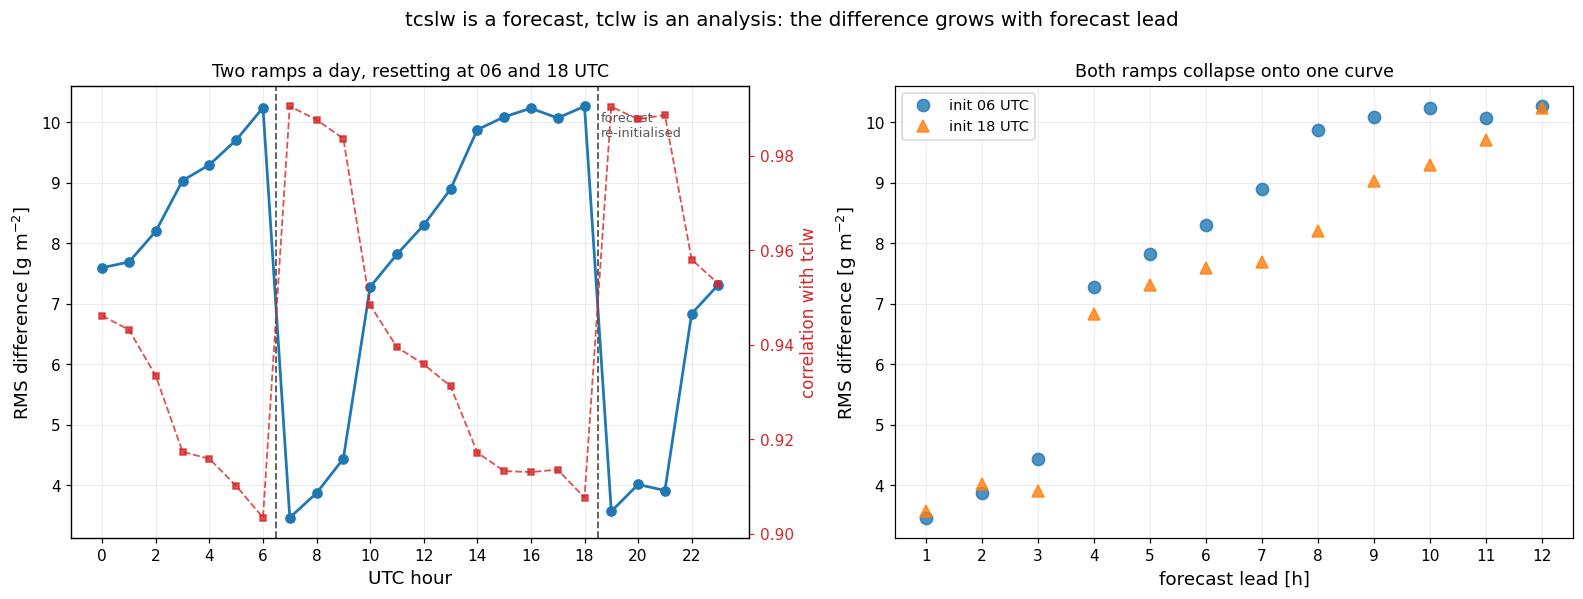

In [2]:
diag = cld.lead_diagnostic(region="barrow")
print(f"{diag['n_files']} files, {diag['n_times']:,} time steps\n")
print(f"{'UTC':>4}{'lead':>6}{'RMS diff':>11}{'corr':>9}{'exceed %':>10}")
for k in range(len(diag["hour"])):
    brk = "   <- forecast re-initialised" if diag["lead"][k] == 1 else ""
    print(f"{diag['hour'][k]:>4}{diag['lead'][k]:>6}{diag['rms'][k]:>11.3f}"
          f"{diag['corr'][k]:>9.4f}{diag['exceed_pct'][k]:>10.2f}{brk}")

from scipy.stats import spearmanr
for key, name in (("rms", "RMS difference"), ("corr", "correlation")):
    rho, pv = spearmanr(diag["lead"], diag[key])
    print(f"\nSpearman(lead, {name:<15}) rho = {rho:+.4f}   p = {pv:.2e}")

cld.fig_forecast_lead(diag, out_dir=SAVE_DIR);

**Result: confirmed.** RMS difference climbs from 3.5 g m⁻² at step 1 to
10.3 at step 12, correlation falls 0.9905 → 0.9055, and both ramps collapse onto
a single curve when plotted against lead. The discontinuities at 18→19 and 06→07
are 2.9×, more than double the largest ordinary hour-to-hour change (2.92 g m⁻²
against 6.70 and 6.78 at the breaks).

At 71 °N in midwinter there is no solar cycle to produce a twice-daily signal
that resets at exactly 06 and 18 UTC. The forecast-lead explanation is the only
one standing.

One nuance: the *exceedance rate* is the weakest of the three diagnostics
(ρ = +0.57). It climbs 18.6% → 32% over leads 1–6 then plateaus — once the
forecast has decorrelated enough that the sign of the difference is near-random,
the fraction exceeding saturates while the magnitude keeps growing. RMS and
correlation are the sharper measures.

In [3]:
SHARED = dict(
    region="barrow",
    years=tuple(range(2014, 2025)),
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,
    ice_fraction_min=0.850,

    min_lwp=0.01,        # g m-2
    min_iwp=0.01,        # g m-2

    min_cloud_fraction=0.95,  # overcast gate (Genie notebook: 0.909)
    lsm_tol=0.01,
    storage="local",
)

A_all = lwph.prepare(liquid_var="tclw",  **SHARED)   # all cloud liquid
A_sc  = lwph.prepare(liquid_var="tcslw", **SHARED)   # supercooled only

cld.check_comparable(A_all, A_sc)      # raises if anything but liquid_var differs
print("\nthe two runs differ only in --liquid-var")

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common ye

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : supercooled liquid water (tcslw)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (co


the two runs differ only in --liquid-var


## 3. Three categories — liquid only, mixed phase, ice only

Two stacked bars per season: all cloud liquid on the left (solid), supercooled
liquid on the right (striped). The lower panel is the percent change per
category, `100 × (tcslw − tclw) / tclw`.

Watch the **mixed-phase** bar in particular. A scene keeps its cloud water
either way; what moves is which side of the ice-fraction boundary it falls on,
so hours leaving *liquid only* mostly reappear in *mixed* or *ice only* rather
than vanishing.

  -> figures/liquid_definitions/barrow_liquid_defs_season_3cat_mean2014-2024.png


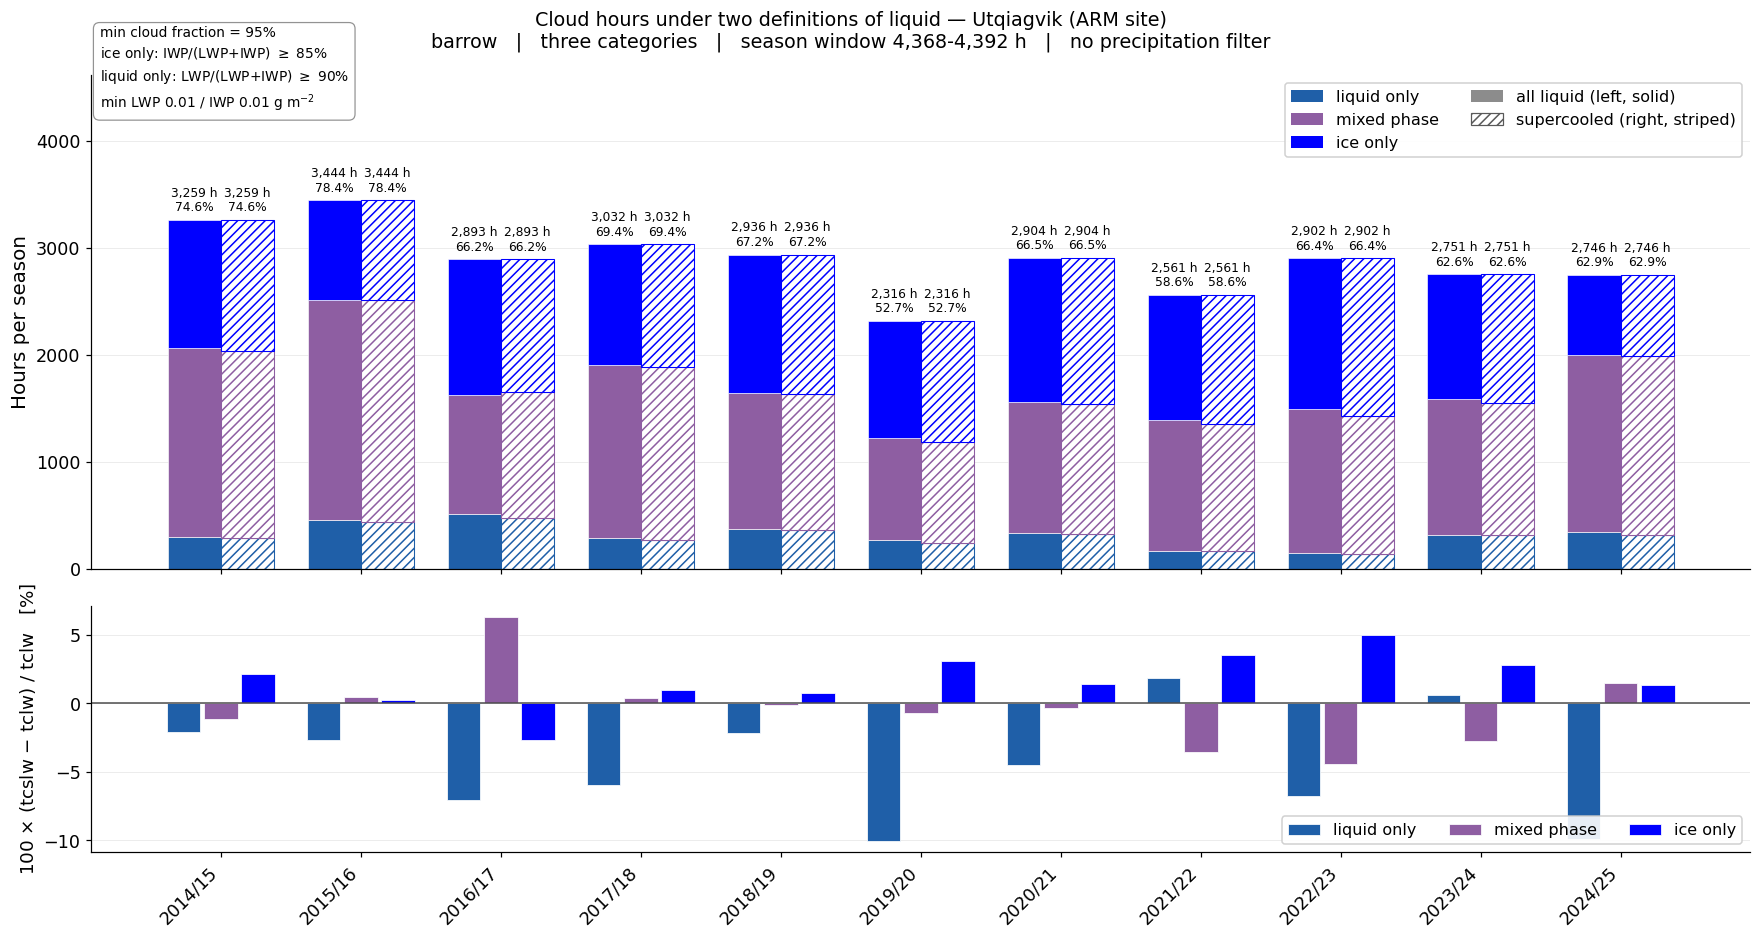

In [4]:
cld.fig_season_liquid_definitions(A_all, A_sc, cats=cld.THREE_WAY,
                                  out_dir=SAVE_DIR);

## 4. Two categories — liquid containing vs ice only

Liquid only and mixed phase merged, matching section 2 of the Genie comparison.
This is the number that matters for "would an instrument have called this a
liquid-bearing cloud", and it is insensitive to where the liquid/mixed boundary
sits.

  -> figures/liquid_definitions/barrow_liquid_defs_season_2cat_mean2014-2024.png


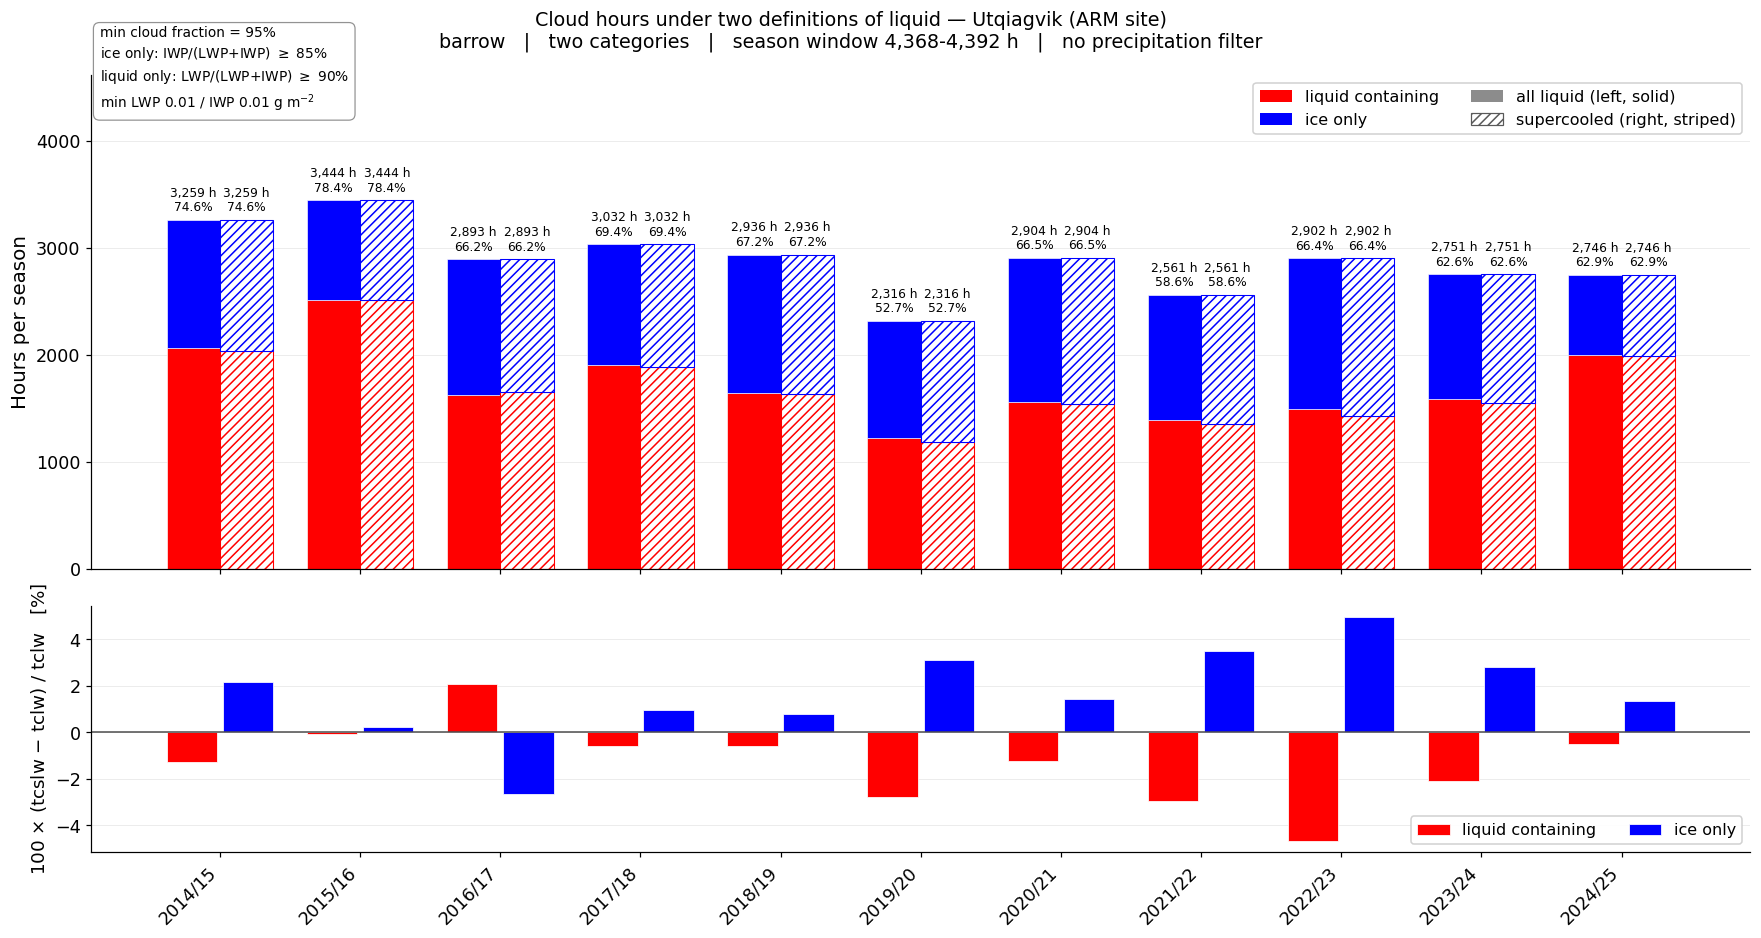

In [5]:
cld.fig_season_liquid_definitions(A_all, A_sc, cats=cld.TWO_WAY,
                                  out_dir=SAVE_DIR);

## 5. The signed accounting

Gains and losses reported apart, because the two fields are not nested.

In [6]:
cld.print_signed_report(A_all, A_sc)

Utqiagvik (ARM site)   |   cloud liquid water (tclw) vs supercooled liquid water (tcslw)
season                   liquid only               mixed phase              liq containi
              tclw    tcslw        %    tclw    tcslw        %    tclw    tcslw        %
2014/15        291      285    -2.1%   1,768    1,748    -1.1%   2,059    2,033    -1.3%
2015/16        450      438    -2.7%   2,059    2,069    +0.5%   2,509    2,507    -0.1%
2016/17        510      474    -7.1%   1,109    1,179    +6.3%   1,619    1,653    +2.1%
2017/18        287      270    -5.9%   1,613    1,619    +0.4%   1,900    1,889    -0.6%
2018/19        372      364    -2.2%   1,270    1,268    -0.2%   1,642    1,632    -0.6%
2019/20        269      242   -10.0%     949      942    -0.7%   1,218    1,184    -2.8%
2020/21        334      319    -4.5%   1,227    1,223    -0.3%   1,561    1,542    -1.2%
2021/22        162      165    +1.9%   1,231    1,187    -3.6%   1,393    1,352    -2.9%
2022/23        148   

## 6. Monthly means — three categories

The season axis collapsed. Whiskers are ±1 standard deviation of the **total**
across seasons — interannual variability, not uncertainty in the mean. Excluded
season-months (`lwph.GENIE_EXCLUDED_MONTHS`) and per-season month lengths follow
the same rules as the Genie comparison, so both notebooks count the same
hours.

  -> figures/liquid_definitions/barrow_liquid_defs_month_3cat_mean2014-2024.png


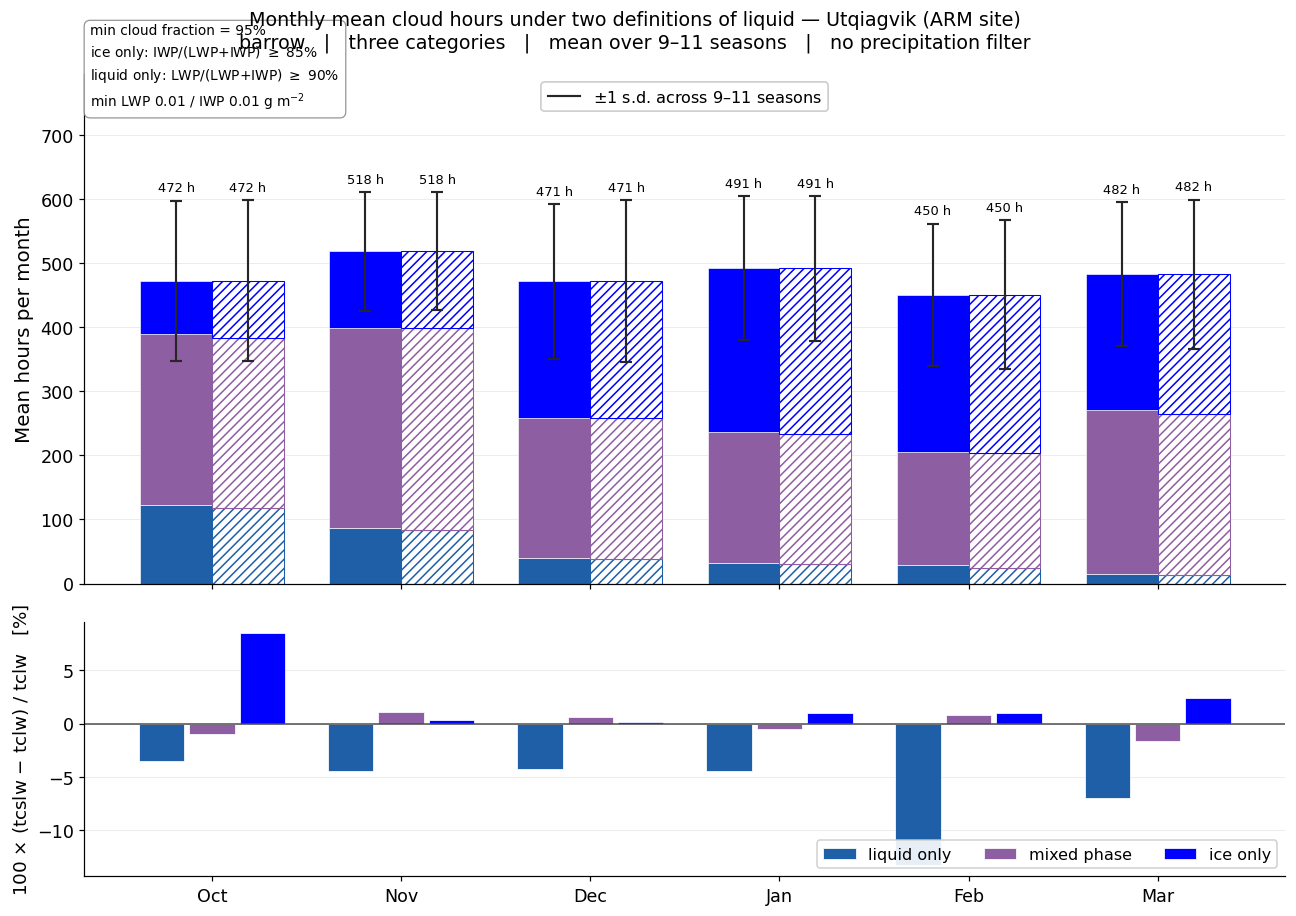

In [7]:
cld.fig_month_liquid_definitions(A_all, A_sc, cats=cld.THREE_WAY,
                                 out_dir=SAVE_DIR);

## 7. Monthly means — two categories

  -> figures/liquid_definitions/barrow_liquid_defs_month_2cat_mean2014-2024.png


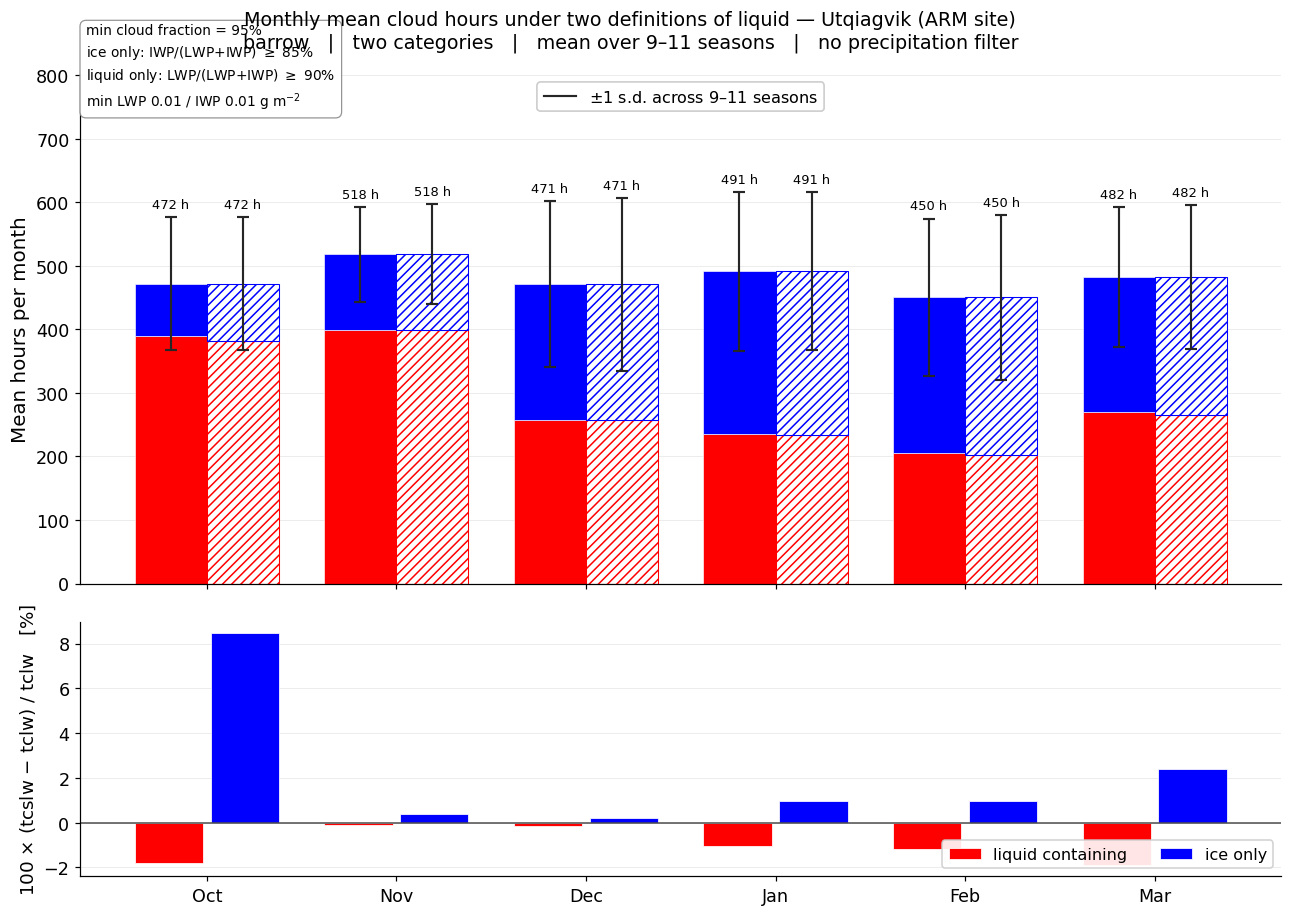

In [8]:
cld.fig_month_liquid_definitions(A_all, A_sc, cats=cld.TWO_WAY,
                                 out_dir=SAVE_DIR);

## 7b. The monthly numbers

Per month, both definitions and the change. The seasonal cycle is the
interesting axis here: supercooled liquid should account for a larger share of
all liquid in the cold months, so a change that varies strongly through the
season is the expected signature and a flat one would be a reason to look
harder at the fields.

In [9]:
import calendar

months, left, sd_l, n_l, series_label = cld.month_categories(A_all)
_m, right, sd_r, _n, _s = cld.month_categories(A_sc)

print(f"{series_label}\n")
print(f"{'month':<7}{'n':>3}" + "".join(
    f"{c:>27}" for c in ("liquid only", "mixed phase", "liquid containing")))
print(f"{'':<7}{'':>3}" + "".join(f"{'tclw':>9}{'tcslw':>9}{'%':>9}"
                                  for _ in range(3)))
for j, m in enumerate(months):
    row = f"{calendar.month_abbr[m]:<7}{int(n_l[j]):>3}"
    for cat in ("liquid", "mixed", "liquid_containing"):
        a, b = left[cat][j], right[cat][j]
        row += f"{a:>9,.0f}{b:>9,.0f}{cld.percent_change(b, a):>+8.1f}%"
    print(row)

tot_a = sum(left[c] for c in cld.THREE_WAY)
tot_b = sum(right[c] for c in cld.THREE_WAY)
print(f"\n{'cloudy':<7}{'':>3}" + "".join(
    f"{a:>9,.0f}{b:>9,.0f}{cld.percent_change(b, a):>+8.1f}%"
    for a, b in [(tot_a.sum(), tot_b.sum())]) + "   (season total, all months)")

Utqiagvik (ARM site)

month    n                liquid only                mixed phase          liquid containing
               tclw    tcslw        %     tclw    tcslw        %     tclw    tcslw        %
Oct      9      123      119    -3.5%      266      264    -1.0%      389      382    -1.8%
Nov      9       87       83    -4.5%      311      315    +1.1%      399      398    -0.1%
Dec     10       40       38    -4.2%      218      219    +0.6%      258      258    -0.2%
Jan     10       32       30    -4.4%      204      203    -0.5%      236      234    -1.1%
Feb     10       29       25   -13.2%      177      178    +0.8%      205      203    -1.2%
Mar     11       14       13    -7.0%      256      252    -1.6%      270      265    -1.9%

cloudy        2,885    2,885    +0.0%   (season total, all months)


## Reading this

Three questions worth keeping separate:

1. **Does the total cloudy time change?** It should barely move — the overcast
   gate is on `tcc`, which neither run touches. A large change here would mean
   the "no phase" residual is absorbing scenes, i.e. columns whose supercooled
   path falls under `min_lwp` while their ice is also under `min_iwp`.
2. **Does the liquid-containing share change?** This is the substantive
   question, and the one relevant to comparing against a ground instrument that
   detects liquid by its radiative signature rather than by temperature.
3. **Does the change vary through the season?** Supercooled liquid should be a
   larger fraction of all liquid in midwinter than in October or March. A change
   that is flat across months would be evidence that the difference between the
   two fields is not primarily thermodynamic — which, given the exceedances
   documented at the top, is a live possibility.

**Caveat carried from the top:** because `tcslw` is not nested inside `tclw` in
these files, none of this cleanly measures "data lost". It measures the
difference between two ERA5 diagnostics that disagree in both directions.

## 8. The comparison restricted to forecast steps 1–3

Sections 3–7 use all 24 hours, so eighteen hours in twenty-four carry a lead of
4 or more. Here the same comparison runs on **07–09 and 19–21 UTC only** — the
six hours where `tcslw` is at steps 1, 2 and 3 and closest to an analysis.

`--utc-hours` narrows the **sample, not the window**: every denominator counts
only the kept steps, so hours-per-season still reads as "hours per season at
this sampling rate" and stays comparable with the all-hours numbers.

### The result runs opposite to the obvious expectation

Removing forecast error makes the difference **larger**, not smaller —
liquid-containing goes from −1.2% to −2.3%, and every category roughly doubles.
Forecast error was *diluting* the signal, not creating it.

The reason is visible in the signed accounting. Forecast error is close to
symmetric noise, so it pushes about as many scenes across a phase boundary in
one direction as the other, and those partly cancel in the aggregate:

| liquid containing | gained | lost |
|---|---|---|
| all 24 hours | +3 h | −26 h |
| steps 1–3 | **+0 h** | −43 h |

At short lead the gains go to **zero** and the change becomes purely
one-directional — which is exactly what a genuine subset relation looks like.
The same holds for ice-only (+43 gained, −0 lost). So once forecast noise is
stripped out, `tcslw` behaves as the physical subset of `tclw` it was always
supposed to be, and the earlier "not nested" finding is fully explained as an
artefact of comparing an analysis against a forecast.

That is independent confirmation of the forecast-lead diagnosis in section 1:
the hypothesis predicted where the error lives, and removing it recovers the
expected physics.

**So the short-lead numbers are the better estimate** of the genuine
supercooled-vs-total-liquid difference. Even these are an underestimate: step 1
is still a forecast, so a residual dilution remains.

**One caveat on sampling.** The `tclw` side is an analysis at every hour, so its
change between the two runs is pure sampling — liquid-containing reads 1,725 h
over all hours against 1,819 h at steps 1–3, i.e. **the six selected hours are
5.4% cloudier than the daily mean**. The Arctic midwinter diurnal cycle is
weaker than at lower latitudes but it is not negligible, and that is larger than
suggested earlier in this notebook. It does not contaminate the comparison,
because the percent difference is formed within each sample so the sampling
affects both sides alike — but the absolute hours in section 8 are not directly
comparable with those in sections 3–7.

In [10]:
LEAD_MAX = 3
SHORT_LEAD_HOURS = cld.hours_for_lead(LEAD_MAX)
print(f"forecast steps 1-{LEAD_MAX} -> UTC hours "
      f"{', '.join(f'{h:02d}' for h in SHORT_LEAD_HOURS)}"
      f"   ({len(SHORT_LEAD_HOURS)} of 24)\n")

A_all_s = lwph.prepare(liquid_var="tclw",  utc_hours=SHORT_LEAD_HOURS, **SHARED)
A_sc_s  = lwph.prepare(liquid_var="tcslw", utc_hours=SHORT_LEAD_HOURS, **SHARED)
cld.check_comparable(A_all_s, A_sc_s)

forecast steps 1-3 -> UTC hours 07, 08, 09, 19, 20, 21   (6 of 24)

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  UTC hours  : 07, 08, 09, 19, 20, 21   (6 of 24)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : supercooled liquid water (tcslw)
  UTC hours  : 07, 08, 09, 19, 20, 21   (6 of 24)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year

### 8.1 Three categories, short lead

  -> figures/liquid_definitions/barrow_liquid_defs_season_3cat_mean2014-2024.png


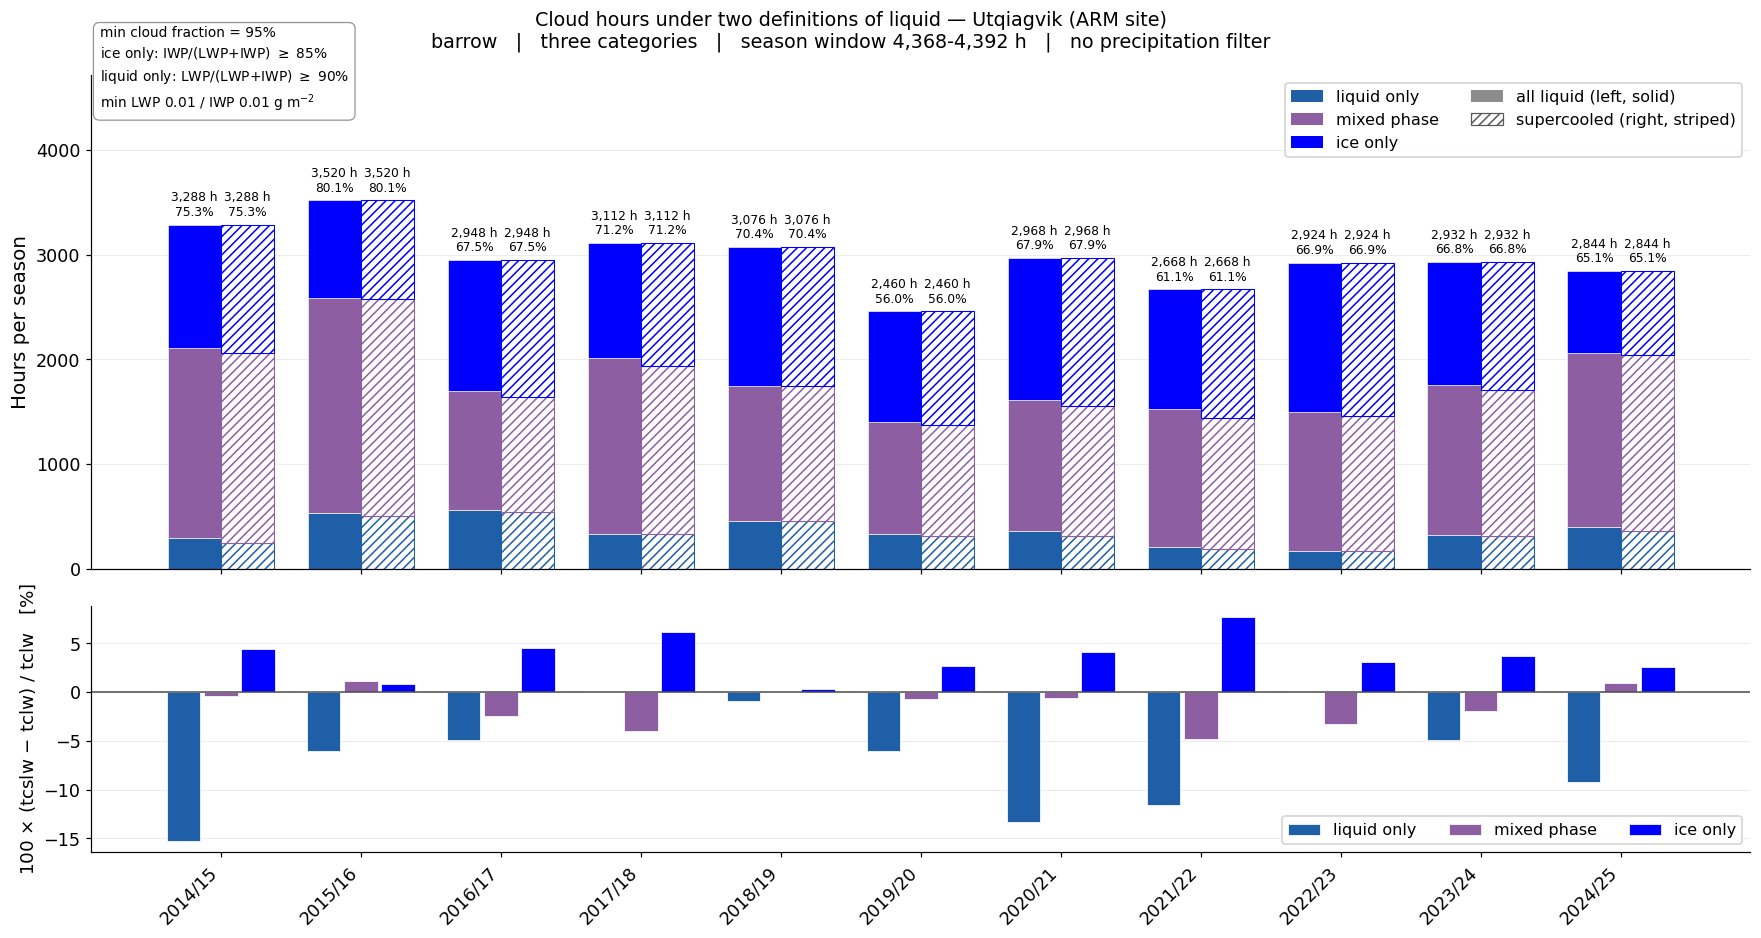

In [11]:
cld.fig_season_liquid_definitions(A_all_s, A_sc_s, cats=cld.THREE_WAY,
                                  out_dir=SAVE_DIR);

### 8.2 The signed accounting, short lead

In [12]:
cld.print_signed_report(A_all_s, A_sc_s)

Utqiagvik (ARM site)   |   cloud liquid water (tclw) vs supercooled liquid water (tcslw)
season                   liquid only               mixed phase              liq containi
              tclw    tcslw        %    tclw    tcslw        %    tclw    tcslw        %
2014/15        288      244   -15.3%   1,824    1,816    -0.4%   2,112    2,060    -2.5%
2015/16        532      500    -6.0%   2,052    2,076    +1.2%   2,584    2,576    -0.3%
2016/17        564      536    -5.0%   1,136    1,108    -2.5%   1,700    1,644    -3.3%
2017/18        328      328    +0.0%   1,680    1,612    -4.0%   2,008    1,940    -3.4%
2018/19        456      452    -0.9%   1,292    1,292    -0.0%   1,748    1,744    -0.2%
2019/20        332      312    -6.0%   1,064    1,056    -0.8%   1,396    1,368    -2.0%
2020/21        360      312   -13.3%   1,252    1,244    -0.6%   1,612    1,556    -3.5%
2021/22        208      184   -11.5%   1,320    1,256    -4.8%   1,528    1,440    -5.8%
2022/23        164   

### 8.3 All hours against short lead

The row that matters is the last: how much of the all-hours difference survives
when forecast error is minimised.

In [13]:
rows = []
for tag, Aa, As in (("all 24 hours", A_all, A_sc),
                    (f"steps 1-{LEAD_MAX}", A_all_s, A_sc_s)):
    _lab, left, _sh, _sl = cld.season_categories(Aa)
    _l2, right, _s2, _s3 = cld.season_categories(As)
    rows.append((tag, {k: (left[k].mean(), right[k].mean())
                       for k in ("liquid", "mixed", "ice", "liquid_containing")}))

cats = ("liquid", "mixed", "ice", "liquid_containing")
names = {"liquid": "liquid only", "mixed": "mixed phase", "ice": "ice only",
         "liquid_containing": "liquid containing"}
print(f"{'category':<20}" + "".join(f"{t:>22}" for t, _ in rows))
print(f"{'':<20}" + "".join(f"{'tclw':>7}{'tcslw':>7}{'%':>8}" for _ in rows))
for cat in cats:
    line = f"{names[cat]:<20}"
    for _t, d in rows:
        a, b = d[cat]
        line += f"{a:>7,.0f}{b:>7,.0f}{cld.percent_change(b, a):>+7.1f}%"
    print(line)

print(f"\n{'category':<20}{'all hours':>12}{'steps 1-3':>12}{'survives':>11}")
for cat in cats:
    p_all = cld.percent_change(*rows[0][1][cat][::-1])
    p_short = cld.percent_change(*rows[1][1][cat][::-1])
    frac = (f"{100 * p_short / p_all:>10.0f}%"
            if abs(p_all) > 0.05 else f"{'n/a':>11}")
    print(f"{names[cat]:<20}{p_all:>+11.1f}%{p_short:>+11.1f}%{frac}")

category                      all 24 hours             steps 1-3
                       tclw  tcslw       %   tclw  tcslw       %
liquid only             316    302   -4.6%    359    336   -6.4%
mixed phase           1,409  1,403   -0.4%  1,460  1,440   -1.3%
ice only              1,161  1,181   +1.7%  1,158  1,200   +3.7%
liquid containing     1,725  1,705   -1.2%  1,819  1,776   -2.3%

category               all hours   steps 1-3   survives
liquid only                -4.6%       -6.4%       139%
mixed phase                -0.4%       -1.3%       336%
ice only                   +1.7%       +3.7%       211%
liquid containing          -1.2%       -2.3%       200%
